In [84]:
import random
from math import sin, cos
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import random
import plotly.graph_objs as go
import plotly.express as px
from scipy import interpolate
import numpy as np
import copy
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import os
from statsmodels.tsa.statespace.sarimax import SARIMAX
import sys

Define a function that has trend, seasonality and random walk components:

$f(t) = 300 + 0.2 t + 5 \sin(t/5) + 20 \cos(t/24) + 100 \sin(t/120) + 20R_{t}$

where $R_{t}$ is a random walk.

In [2]:
def get_time_series_data(length):
    a = .2
    b = 300
    c = 20
    ls = 5
    ms = 20
    gs = 100

    ts = []

    for i in range(length):
        ts.append(b + a * i + ls * sin(i / 5) + ms * cos(i / 24) + gs * sin(i / 120) + c * random.random())

    return ts

Get the time series

In [3]:
ts = get_time_series_data(3000)
print(f"Type of ts: {type(ts)}, Size of ts: {len(ts)}")

Type of ts: <class 'list'>, Size of ts: 3000


Plot the time series

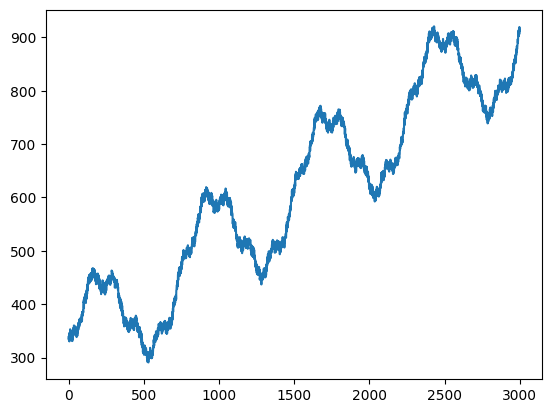

In [4]:
plt.plot(ts)
plt.show()

<h1>Data preparation</h1>

Use sliding windows to make the dataset for training. 

The idea is that the **size of the windows** provides the **number of features** and the **number of sequences** from the sliding-window process is the **number of samples**

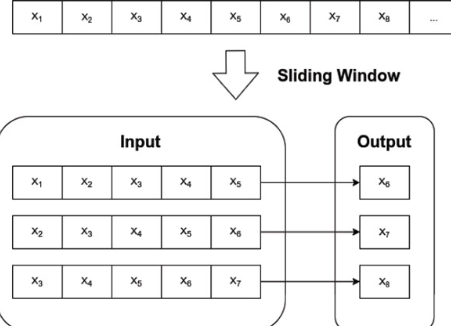

In [5]:
def get_time_series_datasets(features, ts_len):
    ts = get_time_series_data(ts_len)

    X = []
    Y = []
    for i in range(features + 1, ts_len):
        X.append(ts[i - (features + 1):i - 1])
        Y.append([ts[i]])
    
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, shuffle = False)
    X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size = 0.5, shuffle = False)

    x_train = torch.tensor(data = X_train)
    y_train = torch.tensor(data = Y_train)

    x_val = torch.tensor(data = X_val)
    y_val = torch.tensor(data = Y_val)

    x_test = torch.tensor(data = X_test)
    y_test = torch.tensor(data = Y_test)

    return x_train, x_val, x_test, y_train, y_val, y_test

<h2>Let's show the sequences created</h2>

Create the sequences

In [25]:
features = 20
ts_len = len(ts)

X = []
Y = []
for i in range(features + 1, ts_len):
    X.append(ts[i - (features + 1):i - 1])
    Y.append([ts[i]])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, shuffle = False)
X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size = 0.5, shuffle = False)

x_train = torch.tensor(data = X_train)
y_train = torch.tensor(data = Y_train)

x_val = torch.tensor(data = X_val)
y_val = torch.tensor(data = Y_val)

x_test = torch.tensor(data = X_test)
y_test = torch.tensor(data = Y_test)

print(f"Type of X: {type(X)}, Size of X: {len(X)}")
print(f"Type of X_i: {type(X[0])}, Size of X_i: {len(X[0])}")
print(f"Train size: 70%, Test size: 15%, Validation size: 15%")
print(f"Type of X_train: {type(X_train)}, Size of X_train: {len(X_train)}")
print(f"Type of X_train_i: {type(X_train[0])}, Size of X_train_i: {len(X_train[0])}")
print(f"Type of Y: {type(Y)}, Size of Y: {len(Y)}")
print(f"Type of Y_i: {type(Y[0])}, Size of Y_i: {len(Y[0])}")
print(f"Type of Y_train: {type(Y_train)}, Size of Y_train: {len(Y_train)}")
print(f"Type of T_train_i: {type(Y_train[0])}, Size of Y_train_i: {len(Y_train[0])}")


Type of X: <class 'list'>, Size of X: 2979
Type of X_i: <class 'list'>, Size of X_i: 20
Train size: 70%, Test size: 15%, Validation size: 15%
Type of X_train: <class 'list'>, Size of X_train: 2085
Type of X_train_i: <class 'list'>, Size of X_train_i: 20
Type of Y: <class 'list'>, Size of Y: 2979
Type of Y_i: <class 'list'>, Size of Y_i: 1
Type of Y_train: <class 'list'>, Size of Y_train: 2085
Type of T_train_i: <class 'list'>, Size of Y_train_i: 1


Show the sequences of the time series `ts`

In [18]:
import plotly.graph_objs as go

# Define your original time series R and the window size L
L = 50  # Example window size, you can change it based on your use case

# Create the figure
fig = go.Figure()

# Plot the full time series R
fig.add_trace(go.Scatter(
    x=list(range(len(ts))),  # X-axis values as indices of R
    y=ts,  # Full time series R as Y-axis values
    mode='lines',
    name='Original R',
    line=dict(color='blue', width=2),  # Plot R with a solid blue line
    showlegend=True
))

# Define a set of colors for highlighting the background
colors = px.colors.qualitative.Plotly  # Using Plotly's default qualitative color set

# Highlight the background for each sequence based on the window size L
num_sequences = len(ts) // L  # Number of full sequences we can extract from R
for i in range(num_sequences):
    start_idx = i * L
    end_idx = (i + 1) * L
    if i == 0:
        sequence_label = f'Sequence 1'
    else:
        sequence_label = f'Sequence {i}L'
    
    # Add a shaded rectangle behind the plot for the sequence
    fig.add_shape(
        type="rect",
        x0=start_idx,  # Start of the sequence
        x1=end_idx,  # End of the sequence
        y0=min(ts),  # Bottom y-bound (min value of R)
        y1=max(ts),  # Top y-bound (max value of R)
        fillcolor=colors[i % len(colors)],  # Cycle through colors for each sequence
        opacity=0.2,  # Set the opacity to 20% for high transparency
        line_width=0,  # No border around the shaded area
        layer='below'  # Ensure the rectangle is drawn behind the time series
    )

# Update the layout for better visualization
fig.update_layout(
    title='Time series and sequences 1, L, 2L, 3L, ...',
    xaxis_title='Index',
    yaxis_title='Values',
    showlegend=True,
    plot_bgcolor='white',  # Set background color to white
    xaxis=dict(
        title=dict(text='Time', font=dict(size=18, color='black', family='Arial')),
        tickfont=dict(size=14),
        showline=True,  # Show axis line
        linecolor='black',  # Axis line color
        gridcolor='lightgray',  # Set grid color
        gridwidth=1,  # Grid line width
        griddash='dot',  # Make the grid lines dotted
        zeroline=False  # Remove zero line
    ),
    yaxis=dict(
        title=dict(text='Values', font=dict(size=18, color='black', family='Arial')),
        tickfont=dict(size=14),
        showline=True,  # Show axis line
        linecolor='black',  # Axis line color
        gridcolor='lightgray',  # Set grid color
        gridwidth=1,  # Grid line width
        griddash='dot',  # Make the grid lines dotted
        zeroline=False  # Remove zero line
    ),
)

# Show the plot
fig.show()

<h1>Forecast with a FNN</h1>

Definitions:

- `n_inp`: size of the input features
- `l_1`: size of the output features of layer 1
- `l_2`: size of the output features of layer 2
- `n_out`: size of the output features of layer 3 and FNN

Each Linear Layer ($l_{k}$) is just the transformation:

$$
\mathbf{W}_{k}\mathbf{x}_{k} + \mathbf{b}_{k}
$$

where

- $\mathbf{W}_{k} \in \mathbb{R}^{O_{k} \times I_{k}}$
- $\mathbf{x}_{k} \in \mathbb{R}^{I_{k}}$
- $\mathbf{b}_{k} \in \mathbb{R}^{O_{k}}$

and

- $O_{k} = I_{k+1}$
- $O_{k}$ denotes the output size of the layer $k$
- $I_{k}$ denotes the input size of the layer $k$



In [26]:
class FCNN(torch.nn.Module):

    def __init__(self, n_inp, l_1, l_2, n_out):
        super(FCNN, self).__init__()
        self.lin1 = torch.nn.Linear(n_inp, l_1)
        self.lin2 = torch.nn.Linear(l_1, l_2)
        self.lin3 = torch.nn.Linear(l_2, n_out)

    def forward(self, x):
        x1 = F.relu(self.lin1(x))
        x2 = F.relu(self.lin2(x1))
        y = self.lin3(x2)
        return y

Compare the FNN with a dummy model, where

In [27]:
class DummyPredictor(torch.nn.Module):

    def forward(self, x):
        last_values = []
        for r in x.tolist():
            last_values.append([r[-1]])
        return torch.tensor(data = last_values)

Compare with linear interpolation model

In [28]:
class InterpolationPredictor(torch.nn.Module):

    def forward(self, x):
        last_values = []
        values = x.tolist()
        for v in values:
            x = np.arange(0, len(v))
            y = interpolate.interp1d(x, v, fill_value = 'extrapolate')
            last_values.append([y(len(v)).tolist()])
        return torch.tensor(data = last_values)

Compare with HWES classical method

In [31]:
class HwesPredictor(torch.nn.Module):

    def forward(self, x):
        last_values = []
        for r in x.tolist():
            model = ExponentialSmoothing(r)
            results = model.fit()
            forecast = results.forecast()
            last_values.append([forecast[0]])
        return torch.tensor(data = last_values)

<h1>Compare forecast of different models</h1>

Set a random seed

In [32]:
random.seed(1)
torch.manual_seed(1)

Set the size of the time series (emulated) and more importantly the windows size (`features`)

In [33]:
features = 256
ts_len = 3000

x_train, x_val, x_test, y_train, y_val, y_test = get_time_series_datasets(features, ts_len)

Call the models to be compared

In [34]:
net = FCNN(n_inp = features, l_1 = 64, l_2 = 32, n_out = 1)
net.train()
dummy_predictor = DummyPredictor()
interpolation_predictor = InterpolationPredictor()
hwes_predictor = HwesPredictor()

Define the optimizer and the loss function

In [35]:
optimizer = torch.optim.Adam(params = net.parameters())
loss_func = torch.nn.MSELoss()

Make the training loop

In [36]:
best_model = None
min_val_loss = 1000000

training_loss = []
validation_loss = []

for t in range(10000):
    prediction = net(x_train)
    loss = loss_func(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    val_prediction = net(x_val)
    val_loss = loss_func(val_prediction, y_val)

    training_loss.append(loss.item())
    validation_loss.append(val_loss.item())

    if val_loss.item() < min_val_loss:
        best_model = copy.deepcopy(net)
        min_val_loss = val_loss.item()

    if t % 1000 == 0:
        print(f'epoch {t}: train - {round(loss.item(), 4)}, val: - {round(val_loss.item(), 4)}')

epoch 0: train - 287261.5938, val: - 468011.875
epoch 1000: train - 150.4284, val: - 147.0816
epoch 2000: train - 42.3347, val: - 42.9621
epoch 3000: train - 37.5835, val: - 39.7329
epoch 4000: train - 35.663, val: - 38.5326
epoch 5000: train - 35.1931, val: - 37.991
epoch 6000: train - 182.8006, val: - 464.0687
epoch 7000: train - 34.7885, val: - 37.9899
epoch 8000: train - 34.6784, val: - 37.9396
epoch 9000: train - 34.6534, val: - 37.825


Evaluate the model

In [39]:
net.eval()

print('Testing')
print(f'FCNN Loss: {loss_func(best_model(x_test), y_test).item()}')
print(f'Dummy Loss: {loss_func(dummy_predictor(x_test), y_test).item()}')
print(f'Linear Interpolation Loss: {loss_func(interpolation_predictor(x_test), y_test).item()}')
print(f'HWES Loss: {loss_func(hwes_predictor(x_test), y_test).item()}')

Testing
FCNN Loss: 38.07347106933594
Dummy Loss: 75.77690887451172
Linear Interpolation Loss: 220.05862426757812
HWES Loss: 59.23703127724627


Plot the training progress

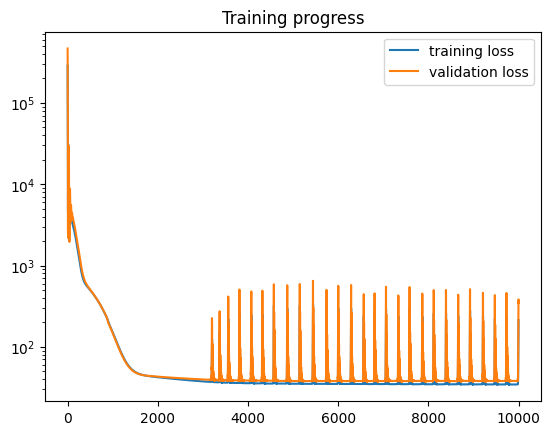

In [40]:
plt.title("Training progress")
plt.yscale("log")
plt.plot(training_loss, label = 'training loss')
plt.plot(validation_loss, label = 'validation loss')
plt.legend()
plt.show()

Plot the FNN on training set

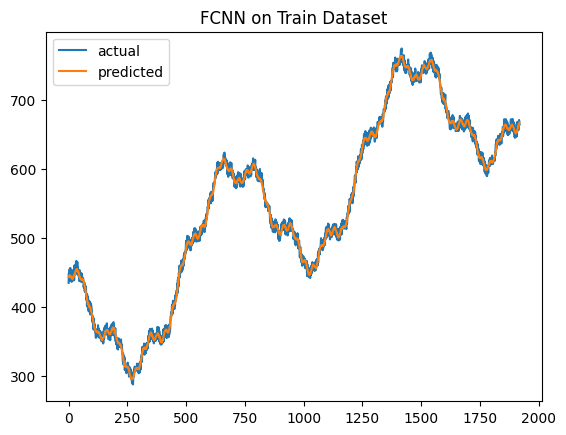

In [41]:

plt.title("FCNN on Train Dataset")
plt.plot(y_train, label = 'actual')
plt.plot(best_model(x_train).tolist(), label = 'predicted')
plt.legend()
plt.show()

Plot the FNN on test set

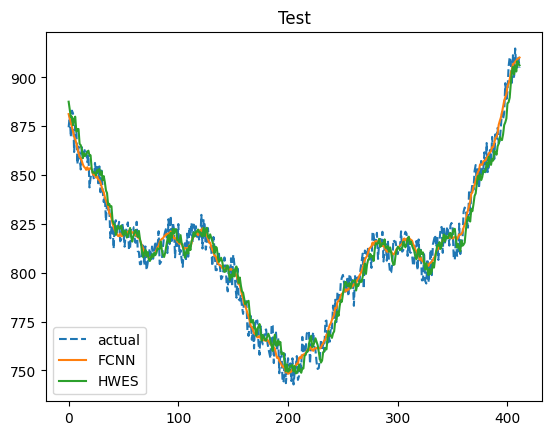

In [42]:
plt.title('Test')
plt.plot(y_test, '--', label = 'actual')
plt.plot(best_model(x_test).tolist(), label = 'FCNN')
plt.plot(hwes_predictor(x_test).tolist(), label = 'HWES')
plt.legend()
plt.show()

<h2>Visualize FNN performance against the HWES performance</h2>

- If FNN is closer to ground truth than HWES, we get a green bar
- If HWES is closer to ground truth than FNN, we get a red bar
- The margin by which one or the other is closer is represented by the amplitud of each bar

In [44]:
test_n = len(y_test)
net_abs_dev = (best_model(x_test) - y_test).abs_()
hwes_abs_dev = (hwes_predictor(x_test) - y_test).abs_()

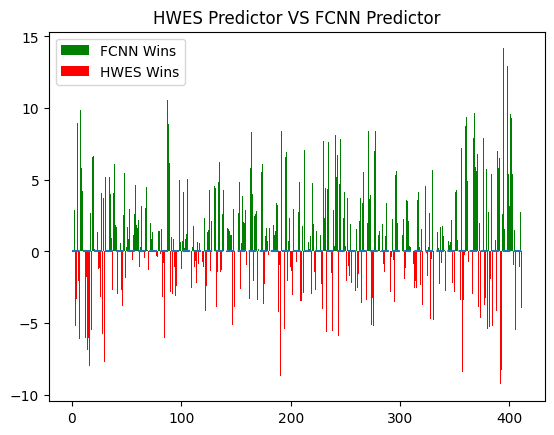

In [43]:
test_n = len(y_test)
net_abs_dev = (best_model(x_test) - y_test).abs_()
hwes_abs_dev = (hwes_predictor(x_test) - y_test).abs_()
diff_pos = F.relu(hwes_abs_dev - net_abs_dev).reshape(test_n).tolist()
diff_min = (-F.relu(net_abs_dev - hwes_abs_dev)).reshape(test_n).tolist()
plt.title('HWES Predictor VS FCNN Predictor')
plt.hlines(0, xmin = 0, xmax = test_n, linestyles = 'dashed')
plt.bar(list(range(test_n)), diff_pos, color = 'g', label = 'FCNN Wins')
plt.bar(list(range(test_n)), diff_min, color = 'r', label = 'HWES Wins')
plt.legend()
plt.show()

<h1>Weather forecast</h1>

In [62]:
def raw_time_series(path_to_dir):
    #dir_path = os.path.dirname(os.path.realpath(__file__))
    ts_df = pd.read_csv(f'{path_to_dir}/data/MET_Office_Weather_Data.csv')
    ts = ts_df.loc[ts_df['station'] == 'sheffield']['tmin'].tolist()
    return ts

In [64]:
ts = raw_time_series('/home/julian/Documents/Github/datascienceblog')
print(f'Count: {len(ts)}')
print(f'Max: {np.nanmax(ts)}')
print(f'Min: {np.nanmin(ts)}')
print(f'Avg: {round(np.nanmean(ts), 2)}')
print(f'Median: {round(np.nanmedian(ts), 2)}')
print(f'Std: {round(np.nanstd(ts), 2)}')
print(f'NA values: {np.count_nonzero(np.isnan(ts))}')

Count: 1650
Max: 14.5
Min: -4.2
Avg: 6.22
Median: 5.7
Std: 4.04
NA values: 27


Interpolate missing values (nan)

In [68]:
def interpolated_time_series(path_to_dir):
    #dir_path = os.path.dirname(os.path.realpath(__file__))
    ts_df = pd.read_csv(f'{path_to_dir}/data/MET_Office_Weather_Data.csv')
    ts = ts_df.loc[ts_df['station'] == 'sheffield']['tmin']\
        .interpolate().dropna().tolist()
    return ts

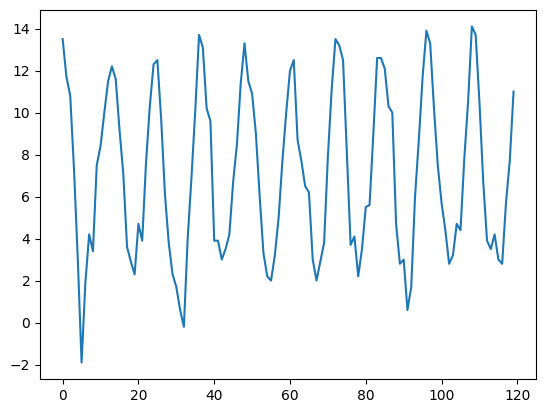

In [69]:
ts = interpolated_time_series('/home/julian/Documents/Github/datascienceblog')
plt.plot(ts[-120:])
plt.show()

<h1>NN model</h1>

Our NN will have a:

- Feature extraction layer
- Decision-making layer

More definitions:

- `n_inp`: size of the input. An integer is expected
- `l_1`: size of the output of the first decision-making layer. An integer is expected
- `l_2`: size of the output of the second decision-making layer. An integer is expected
- `conv1_out`: number of output channels after the first convolution layer. An integer is expected
- `conv2_out`: number of output channels after the second convolution layer. Equals to `conv1_out`$*2$
- `conv1_kernel`: size of the kernel for the first convolutional layer. Either an integer or a tuple is expected
- `conv2_kernel`: size of the kernel for the second convolutional layer. Either an integer or a tuple is expected
- `drop1`: dropout layer parameter $p$


To be aware:

- Convolutional layers are 1D convlutional layer, since the time series is 1D
- The last layer (or the output layer) of the architecture is a LL with size 1, since only 1 value is predicted.
- Convlutional layers require 2D tensor

In [72]:
class DL(torch.nn.Module):
    def __init__(self, n_inp, l_1, l_2, conv1_out, conv1_kernel, conv2_kernel, drop1 = 0):
        super(DL, self).__init__()
        conv1_out_ch = conv1_out
        conv2_out_ch = conv1_out * 2
        conv1_kernel = conv1_kernel
        conv2_kernel = conv2_kernel
        self.dropout_lin1 = drop1

        self.pool = torch.nn.MaxPool1d(kernel_size = 2)

        self.conv1 = torch.nn.Conv1d(in_channels = 1, out_channels = conv1_out_ch, kernel_size = conv1_kernel,
                                     padding = conv1_kernel - 1)

        self.conv2 = torch.nn.Conv1d(in_channels = conv1_out_ch, out_channels = conv2_out_ch,
                                     kernel_size = conv2_kernel,
                                     padding = conv2_kernel - 1)

        # feature_tensor is used here only to get the input dimension of the first LL
        feature_tensor = self.feature_stack(torch.Tensor([[0] * n_inp]))
        self.lin1 = torch.nn.Linear(feature_tensor.size()[1], l_1)
        self.lin2 = torch.nn.Linear(l_1, l_2)
        self.lin3 = torch.nn.Linear(l_2, 1) # 

    # These are the feature extraction layers (convolutional layers)
    def feature_stack(self, x):
        # assumes x is [[...]]
        x = x.unsqueeze(1) # Adds one more inner dimension: [[[...]]], which is a requirement of the conv layers
        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))
        x = x.flatten(start_dim = 1)
        return x

    # These are the decison-making layers (linear layers):
    def fc_stack(self, x):
        x1 = F.dropout(F.relu(self.lin1(x)), p = self.dropout_lin1)
        x2 = F.relu(self.lin2(x1))
        y = self.lin3(x2)
        return y

    def forward(self, x):
        x = self.feature_stack(x)
        y = self.fc_stack(x)
        return y

<h1>SARIMA model</h1>

In [73]:
class SarimaxPredictor(torch.nn.Module):

    def forward(self, x):
        last_values = []
        l = x.tolist()
        counter = 0
        for r in l:
            model = SARIMAX(r,
                            order = (1, 1, 1),
                            seasonal_order = (1, 1, 1, 12))
            results = model.fit(disp = 0)
            forecast = results.forecast()
            last_values.append([forecast[0]])
            counter = counter + 1
            print(f'debug: SARIMA calculation {counter} / {len(l)}')

        return torch.tensor(data = last_values)

<h1>HWES model</h1>

In [74]:
class HwesPredictor(torch.nn.Module):

    def forward(self, x):
        last_values = []
        for r in x.tolist():
            model = ExponentialSmoothing(r,
                                         trend = None,
                                         seasonal = "add",
                                         seasonal_periods = 12
                                         )
            results = model.fit()
            forecast = results.forecast()
            last_values.append([forecast[0]])
        return torch.tensor(data = last_values)

<h1>Compare models</h1>

Set random seed

In [75]:
random.seed(1)
torch.manual_seed(1)

Get the datasets

In [79]:
def sliding_window(ts, features):
    X = []
    Y = []

    for i in range(features + 1, len(ts) + 1):
        X.append(ts[i - (features + 1):i - 1])
        Y.append([ts[i - 1]])

    return X, Y

def get_training_datasets(features, test_len, path_to_dir):
    ts = interpolated_time_series(path_to_dir)
    X, Y = sliding_window(ts, features)

    X_train, Y_train, X_test, Y_test = X[0:-test_len], \
                                       Y[0:-test_len], \
                                       X[-test_len:], \
                                       Y[-test_len:]

    train_len = round(len(ts) * 0.7)

    X_train, X_val, Y_train, Y_val = X_train[0:train_len],\
                                     X_train[train_len:],\
                                     Y_train[0:train_len],\
                                     Y_train[train_len:]

    x_train = torch.tensor(data = X_train)
    y_train = torch.tensor(data = Y_train)

    x_val = torch.tensor(data = X_val)
    y_val = torch.tensor(data = Y_val)

    x_test = torch.tensor(data = X_test)
    y_test = torch.tensor(data = Y_test)

    return x_train, x_val, x_test, y_train, y_val, y_test

In [80]:
features = 120
path_to_dir = '/home/julian/Documents/Github/datascienceblog'
x_train, x_val, x_test, y_train, y_val, y_test =\
    get_training_datasets(features, 60, path_to_dir)

Get models

In [81]:
net = DL(
    n_inp = features,
    l_1 = 400,
    l_2 = 48,
    conv1_out = 6,
    conv1_kernel = 36,
    conv2_kernel = 12,
    drop1 = .1
)
net.train()

sarima_predictor = SarimaxPredictor()
hwes_predictor = HwesPredictor()

Define optimizer and loss fcn

In [82]:
optimizer = torch.optim.Adam(params = net.parameters())
abs_loss = torch.nn.L1Loss()

Training loop

In [85]:
best_model = None
min_val_loss = sys.maxsize

training_loss = []
validation_loss = []

for t in range(150):

    prediction = net(x_train)
    loss = abs_loss(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    val_prediction = net(x_val)
    val_loss = abs_loss(val_prediction, y_val)

    training_loss.append(loss.item())
    validation_loss.append(val_loss.item())

    if val_loss.item() < min_val_loss:
        best_model = copy.deepcopy(net)
        min_val_loss = val_loss.item()

    if t % 10 == 0:
        print(f'epoch {t}: train - {round(loss.item(), 4)}, '
              f'val: - {round(val_loss.item(), 4)}')

epoch 0: train - 6.1657, val: - 6.2088
epoch 10: train - 2.4834, val: - 2.4052
epoch 20: train - 1.3156, val: - 1.5125
epoch 30: train - 1.0293, val: - 0.9551
epoch 40: train - 1.0598, val: - 0.9523
epoch 50: train - 1.0113, val: - 1.0287
epoch 60: train - 1.0016, val: - 0.9548
epoch 70: train - 0.9842, val: - 0.9828
epoch 80: train - 0.9821, val: - 0.9776
epoch 90: train - 0.9864, val: - 0.9714
epoch 100: train - 0.972, val: - 0.976
epoch 110: train - 0.9528, val: - 0.9553
epoch 120: train - 0.9515, val: - 0.974
epoch 130: train - 0.9299, val: - 1.0017
epoch 140: train - 0.9142, val: - 0.992


Evaluate model on test set

In [86]:
best_model.eval()

dl_prediction = best_model(x_test)
sarima_prediction = sarima_predictor(x_test)
hwes_prediction = hwes_predictor(x_test)

dl_abs_loss = round(abs_loss(dl_prediction, y_test).item(), 4)
sarima_abs_loss = round(abs_loss(sarima_prediction, y_test).item(), 4)
hwes_abs_loss = round(abs_loss(hwes_prediction, y_test).item(), 4)

print('===')
print('Results on Test Dataset')
print(f'DL Loss: {dl_abs_loss}')
print(f'SARIMA Loss: {sarima_abs_loss}')
print(f'HWES Loss: {hwes_abs_loss}')

debug: SARIMA calculation 1 / 60
debug: SARIMA calculation 2 / 60
debug: SARIMA calculation 3 / 60
debug: SARIMA calculation 4 / 60
debug: SARIMA calculation 5 / 60
debug: SARIMA calculation 6 / 60
debug: SARIMA calculation 7 / 60
debug: SARIMA calculation 8 / 60
debug: SARIMA calculation 9 / 60
debug: SARIMA calculation 10 / 60
debug: SARIMA calculation 11 / 60
debug: SARIMA calculation 12 / 60
debug: SARIMA calculation 13 / 60
debug: SARIMA calculation 14 / 60
debug: SARIMA calculation 15 / 60
debug: SARIMA calculation 16 / 60
debug: SARIMA calculation 17 / 60
debug: SARIMA calculation 18 / 60
debug: SARIMA calculation 19 / 60
debug: SARIMA calculation 20 / 60
debug: SARIMA calculation 21 / 60
debug: SARIMA calculation 22 / 60
debug: SARIMA calculation 23 / 60
debug: SARIMA calculation 24 / 60
debug: SARIMA calculation 25 / 60
debug: SARIMA calculation 26 / 60
debug: SARIMA calculation 27 / 60
debug: SARIMA calculation 28 / 60
debug: SARIMA calculation 29 / 60
debug: SARIMA calculati

Plot results

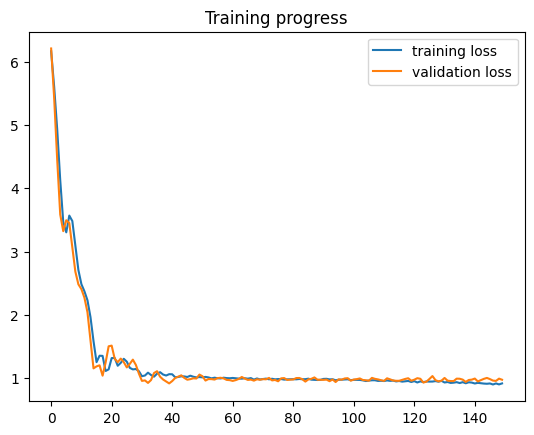

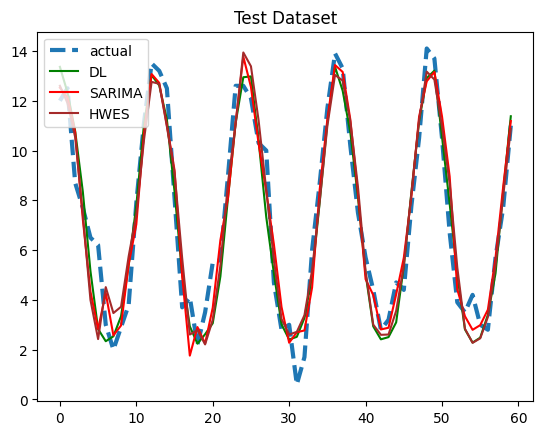

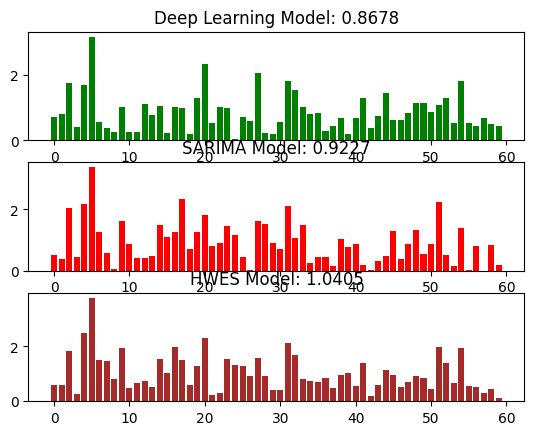

In [87]:
plt.title("Training progress")
plt.plot(training_loss, label = 'training loss')
plt.plot(validation_loss, label = 'validation loss')
plt.legend()
plt.show()

plt.title('Test Dataset')
plt.plot(y_test, '--', label = 'actual', linewidth = 3)
plt.plot(best_model(x_test).tolist(), label = 'DL', color = 'g')
plt.plot(sarima_prediction.tolist(), label = 'SARIMA', color = 'r')
plt.plot(hwes_prediction.tolist(), label = 'HWES', color = 'brown')
plt.legend()
plt.show()

test_n = len(y_test)
dl_abs_dev = (dl_prediction - y_test).abs_()
sarima_abs_dev = (sarima_prediction - y_test).abs_()
hwes_abs_dev = (hwes_prediction - y_test).abs_()

fig = plt.figure()

ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)

ax1.set_title(f'Deep Learning Model: {dl_abs_loss}')
ax1.bar(list(range(test_n)), dl_abs_dev.view(test_n).tolist(), color = 'g')

ax2.set_title(f'SARIMA Model: {sarima_abs_loss}')
ax2.bar(list(range(test_n)), sarima_abs_dev.view(test_n).tolist(), color = 'r')

ax3.set_title(f'HWES Model: {hwes_abs_loss}')
ax3.bar(list(range(test_n)), hwes_abs_dev.view(test_n).tolist(), color = 'brown')

plt.show()